In [ ]:
#Bachelor's Thesis Research | Lumbini Banijya Campus | Tribhuvan University


"""
This project presents a custom-built quantitative trading strategy for the Nepal Stock Exchange (NEPSE), designed as part of
my Bachelor's thesis research. The strategy is a long-only, rule-based system that combines key technical indicators—Z-score,
RSI (Relative Strength Index), and the 240-day Moving Average (MA240)— to identify optimal entry points based on trend 
conditions and mean reversion signals.

The strategy applies a dynamic position sizing model, where risk per trade is set at 4% of the most recently closed capital 
and adjusts based on consecutive wins or losses. The primary objective of the research is to evaluate whether this 
quantitative approach can outperform traditional Buy & Hold strategies in terms of risk-adjusted returns and capital 
preservation.

The strategy was developed independently, with conceptual guidance from my academic supervisor and debugging assistance from 
AI tools like ChatGPT. Backtesting results, including performance metrics such as Sharpe ratio, maximum drawdown, and Monte 
Carlo simulations, are presented to assess robustness. This project aims to demonstrate the effectiveness of data-driven 
trading strategies in the NEPSE market. But here i havent provided Monte carlo simulations code.
"""

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from ta.momentum import RSIIndicator
import warnings
import matplotlib.dates as mdates
import seaborn as sns
import scipy.stats as stats
from scipy.stats import skew, kurtosis
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings("ignore")

# Load data
file_path = "C:\\Users\\Dell\\OneDrive\\Desktop\\Project Report\\ShareSansar_Index_History.xlsx"
data = pd.read_excel(file_path, parse_dates=["Date"], index_col="Date")
data["Close"] = pd.to_numeric(data["Close"], errors='coerce')
data.tail()

,Symbol,Close
Date,,
2025-03-24,NEPSE,2640.78
2025-03-25,NEPSE,2582.73
2025-03-26,NEPSE,2621.86
2025-03-27,NEPSE,2663.30
2025-03-30,NEPSE,2693.12


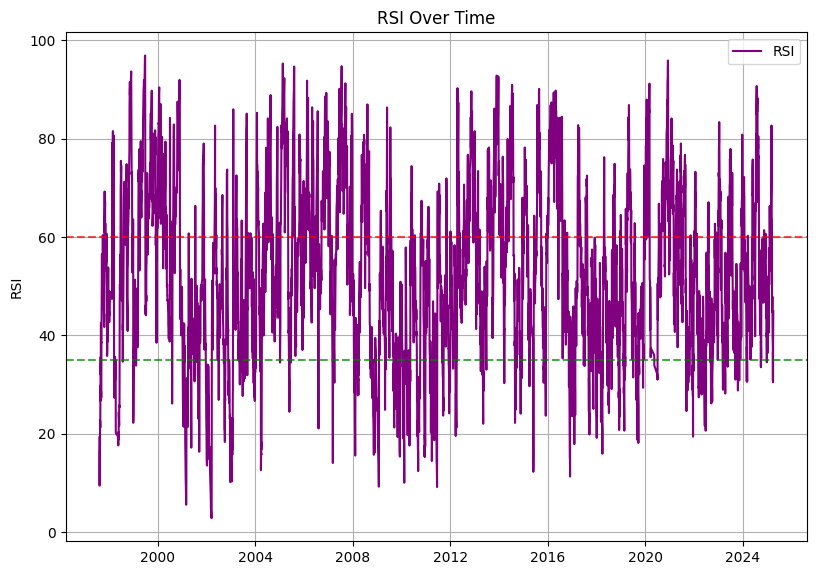

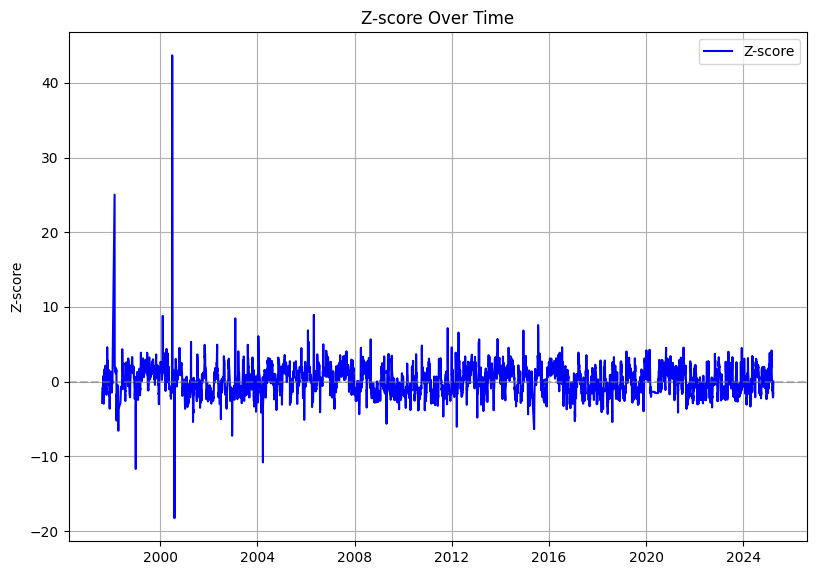

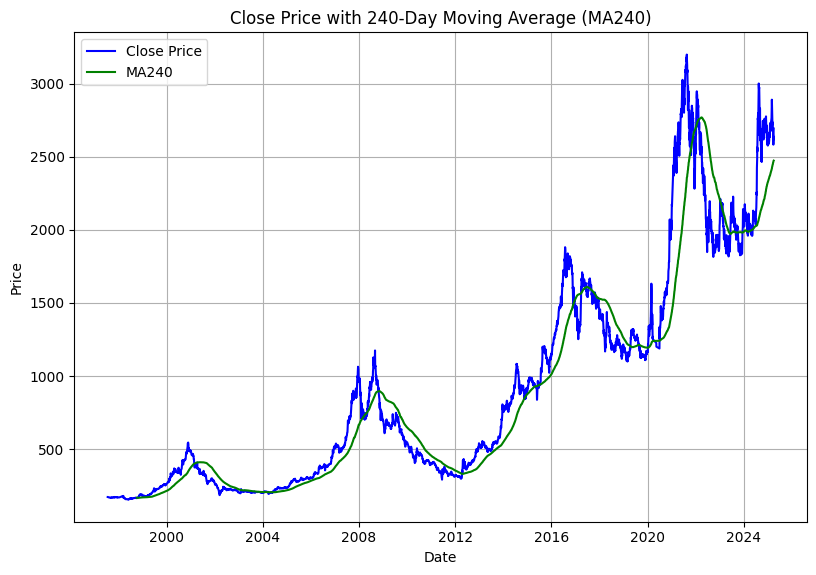

In [2]:
# Configuration
CONFIG = {
    "initial_balance": 1_000_000,
    "base_risk": 0.02,
    "reduced_risk": 0.01,
    "reward_to_risk": 4.5,
    "slippage": 0.0025,
    "zscore_window": 15,
    "rsi_window": 14,
    "ma240_window": 240,
    "dynamic_z_window": 120,
    "ma70_window": 70,
}

# Indicators
data["Mean"] = data["Close"].rolling(CONFIG['zscore_window']).mean().shift()
data["Std"] = data["Close"].rolling(CONFIG['zscore_window']).std().shift()
data["Z-score"] = (data["Close"] - data["Mean"]) / data["Std"]
data["RSI"] = RSIIndicator(data["Close"], window=CONFIG['rsi_window']).rsi().shift()
data["MA240"] = data["Close"].rolling(CONFIG['ma240_window']).mean().shift()
data["Dynamic Z"] = data["Z-score"].rolling(CONFIG['dynamic_z_window']).quantile(0.1).shift()
data["MA70"] = data["Close"].rolling(CONFIG['ma70_window']).mean().shift()

#plot RSI
fig1 = plt.figure(figsize=(8.27, 5.85))
plt.plot(data["RSI"], label="RSI", color='purple')
plt.axhline(60, color='red', linestyle='--', alpha=0.7)
plt.axhline(35, color='green', linestyle='--', alpha=0.7)
plt.title("RSI Over Time")
plt.ylabel("RSI")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

#plot Z-score
fig2 = plt.figure(figsize=(8.27, 5.85))
plt.plot(data["Z-score"], label="Z-score", color='blue')
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.title("Z-score Over Time")
plt.ylabel("Z-score")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.27, 5.85))
plt.plot(data.index, data["Close"], label="Close Price", color='blue')
plt.plot(data.index, data["MA240"], label="MA240", color='green')
plt.title("Close Price with 240-Day Moving Average (MA240)")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
# Signal Generation
data["Mean Reversion Signal"] = (
    (data["Z-score"] < data["Dynamic Z"]) & (data["RSI"] > 35) & (data["RSI"] < 60) &
    (data["Close"] > data["MA240"]) 
)
data["Momentum Signal"] = (
    (data["Close"] > 1.05 * data["MA240"]) & (data["Z-score"] > 1) &
    (data["Close"] < 1.3 * data["MA240"]) &
    (data["Close"] > data["Close"].shift(3))
)

momentum_cooldown_days = 4
meanrev_cooldown_days = 3

data["Trade Type"] = "None"
data.loc[data["Momentum Signal"], "Trade Type"] = "Momentum"
data.loc[data["Mean Reversion Signal"], "Trade Type"] = "Mean Reversion"
data["Long Signal"] = data["Trade Type"] != "None"

# Backtest
cash = CONFIG['initial_balance']
closed_capital = CONFIG['initial_balance']
risk_per_trade = CONFIG['base_risk']
loss_streak = 0
active_trades = []
trades = []
portfolio_value = []

last_momentum_trade_date = data.index[0] - pd.Timedelta(days=100)
last_menrev_trade_date = data.index[0] - pd.Timedelta(days=100)

closed_capital_history = []
utilized_history = []
unused_history = []
actual_cap = []
used_cap = []
unused_cap = []

for date, row in (data.iterrows()):
    # === Ensure portfolio value is updated exactly once per date ===
    current_value = cash + sum(t["Shares"] * row["Close"] for t in active_trades)
    portfolio_value.append(current_value)

    actual_cap.append(closed_capital)
    used = closed_capital - cash
    used_cap.append(used)
    unused_cap.append(cash)
    # === Capital tracking starts here ===
    closed_capital_history.append(closed_capital)
    if row["Long Signal"]:
        if row["Trade Type"] == "Mean Reversion":           
           stop_loss = row["MA70"] 
        if row["Trade Type"] == "Momentum":
            stop_loss = row["Close"] * 0.96
        risk_per_share = max(row["Close"] - stop_loss, 1e-5)
        required_risk_amt = closed_capital * risk_per_trade
        required_cost = required_risk_amt / risk_per_share * row["Close"] if risk_per_share > 0 else 0
        if required_cost <= cash:
            utilized_history.append(required_cost)
            unused_history.append(cash - required_cost)
        else:
            utilized_history.append(0)
            unused_history.append(cash)
    else:
        utilized_history.append(0)
        unused_history.append(cash)

    # === Skip momentum trade if within cooldown ===
    if row["Trade Type"] == "Momentum" and (date - last_momentum_trade_date).days < momentum_cooldown_days:
        continue

    if row["Trade Type"] == "Mean Reversion" and (date - last_menrev_trade_date).days < meanrev_cooldown_days:
        continue

    # === Trade Entry ===
    if row["Long Signal"] and len(active_trades) < 4 and cash >= required_cost:
        duplicate_trade = any(
            t["Date"] == date and t["Trade Type"] == row["Trade Type"] and np.isclose(t["Entry"], row["Close"])
            for t in trades
        )
        if duplicate_trade:
            continue
        if row["Trade Type"] == "Mean Reversion":           
           stop_loss = row["MA70"] 

        if row["Trade Type"] == "Momentum":
            stop_loss = row["Close"] * 0.96
        risk_per_share = max(row["Close"] - stop_loss, 1e-5)
        if risk_per_share > 0:
            risk_amt = closed_capital * risk_per_trade
            shares = risk_amt / risk_per_share
            total_cost = shares * row["Close"]
            if total_cost <= cash:
                entry = row["Close"]
                target = entry + CONFIG['reward_to_risk'] * (entry - stop_loss)
                trade = {
                    "Date": date, "Entry": entry, "Stop Loss": stop_loss,
                    "Target": target, "Shares": shares, "Exit": None, "P/L": None,
                    "Z-score": row["Z-score"], "RSI": row["RSI"],
                    "MA240": row["MA240"], "Trade Type": row["Trade Type"]
                }
                active_trades.append(trade)
                trades.append(trade)
                cash -= total_cost

                if row["Trade Type"] == "Momentum":
                   last_momentum_trade_date = date
                elif row["Trade Type"] == "Mean Reversion":
                     last_menrev_trade_date = date

        # === Exit Logic ===
    for trade in active_trades[:]:
        if row["Close"] <= trade["Stop Loss"] or row["Close"] >= trade["Target"]:
            exit_price = trade["Target"] * (1 + CONFIG['slippage']) if row["Close"] >= trade["Target"] else trade["Stop Loss"] * (1 - CONFIG['slippage'])
            trade["Exit"] = exit_price
            trade["P/L"] = trade["Shares"] * (exit_price - trade["Entry"])
            cash += trade["Shares"] * exit_price
            trade["Exit Date"] = date
            closed_capital += trade["P/L"]

            if trade["P/L"] < 0:
                loss_streak += 1
            else:
                loss_streak = 0

            risk_per_trade = CONFIG['reduced_risk'] if loss_streak >= 4 else CONFIG['base_risk']
            active_trades.remove(trade)

# Match portfolio length with data index
data = data.iloc[:len(portfolio_value)]
portfolio = pd.Series(portfolio_value, index=data.index)
daily_returns = portfolio.pct_change().dropna()

In [5]:
# Metrics
def performance_metrics(returns, equity_curve):
    total_return = equity_curve[-1] / equity_curve[0] - 1
    cagr = (equity_curve[-1] / equity_curve[0])**(252 / len(equity_curve)) - 1
    sharpe = returns.mean() / returns.std() * np.sqrt(252)
    sortino = returns.mean() / returns[returns < 0].std() * np.sqrt(252)
    return total_return, cagr, sharpe, sortino

def calculate_max_drawdown(equity):
    roll_max = equity.cummax()
    drawdown = equity / roll_max - 1
    return drawdown.min()

# Buy & Hold
buy_hold = data["Close"] / data["Close"].iloc[0] * CONFIG['initial_balance']
buy_hold_returns = buy_hold.pct_change().dropna()

q_total, q_cagr, q_sharpe, q_sortino = performance_metrics(daily_returns, portfolio)
bh_total, bh_cagr, bh_sharpe, bh_sortino = performance_metrics(buy_hold_returns, buy_hold)
quant_max_drawdown = calculate_max_drawdown(portfolio)
bh_max_drawdown = calculate_max_drawdown(buy_hold)
closed_trades = [t for t in trades if t["Exit"] is not None]
profits = [t["P/L"] for t in closed_trades]
wins = [p for p in profits if p > 0]
losses = [p for p in profits if p < 0]
win_rate = len(wins) / len(profits) if profits else 0
avg_win = np.mean(wins) if wins else 0
avg_loss = np.mean(losses) if losses else 0
gross_profit = sum(wins)
gross_loss = abs(sum(losses)) if losses else 1
profit_factor = gross_profit / gross_loss
recovery_factor = (portfolio.iloc[-1] - CONFIG['initial_balance']) / abs(quant_max_drawdown * CONFIG['initial_balance']) if quant_max_drawdown else 0

# Summary Print
print("--- Performance Summary ---")
print(f"Quant Strategy: Total Return: {q_total:.2%}, CAGR: {q_cagr:.2%}, Sharpe: {q_sharpe:.2f}, Sortino: {q_sortino:.2f}")
print(f"Buy & Hold     : Total Return: {bh_total:.2%}, CAGR: {bh_cagr:.2%}, Sharpe: {bh_sharpe:.2f}, Sortino: {bh_sortino:.2f}")

print("\n--- Additional Metrics ---")
print(f"Quant Strategy Max Drawdown     : {quant_max_drawdown:.2%}")
print(f"Buy & Hold Max Drawdown         : {bh_max_drawdown:.2%}")
print(f"Quant Strategy Win Rate         : {win_rate:.2%}")
print(f"Quant Strategy Avg Win          : Rs{avg_win:,.2f}")
print(f"Quant Strategy Avg Loss         : Rs{avg_loss:,.2f}")
print(f"Quant Strategy Profit Factor    : {profit_factor:.2f}")
print(f"Quant Strategy Recovery Factor  : {recovery_factor:.2f}")

--- Performance Summary ---
Quant Strategy: Total Return: 2877.27%, CAGR: 14.38%, Sharpe: 1.39, Sortino: 1.35
Buy & Hold     : Total Return: 1454.38%, CAGR: 11.47%, Sharpe: 0.64, Sortino: 0.89

--- Additional Metrics ---
Quant Strategy Max Drawdown     : -28.11%
Buy & Hold Max Drawdown         : -75.16%
Quant Strategy Win Rate         : 53.64%
Quant Strategy Avg Win          : Rs676,702.26
Quant Strategy Avg Loss         : Rs-231,301.33
Quant Strategy Profit Factor    : 3.38
Quant Strategy Recovery Factor  : 102.37


In [7]:
# Print all trades
trade_df = pd.DataFrame(trades)
pd.set_option('display.max_rows', None)
print("\n--- Trades Executed ---")
print(trade_df[["Date", "Entry", "Target", "Stop Loss", "Exit", "P/L", "Trade Type", "Z-score", "MA240", "RSI"]].head())



--- Trades Executed ---
        Date   Entry      Target   Stop Loss        Exit            P/L  \
0 1998-11-04  176.81  208.635800  169.737600  209.157390   91475.000000   
1 1998-11-08  182.06  214.830800  174.777600  215.367877   91475.000000   
2 1999-06-03  210.00  247.800000  201.600000  248.419500   99842.675625   
3 1999-06-20  223.30  263.494000  214.368000  213.832080  -25078.540000   
4 1999-07-07  211.95  257.716929  201.779571  258.361221  105675.444684   

       Trade Type   Z-score       MA240        RSI  
0        Momentum  3.261548  167.912667  83.770685  
1        Momentum  3.191408  167.985750  89.404713  
2        Momentum  1.851284  177.142458  89.924836  
3        Momentum  3.865887  179.457833  93.033253  
4  Mean Reversion -1.192643  182.829208  46.227051  


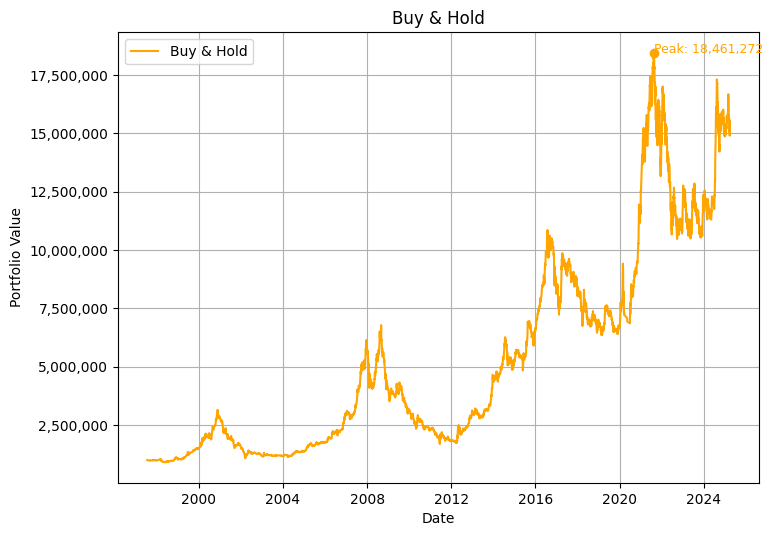

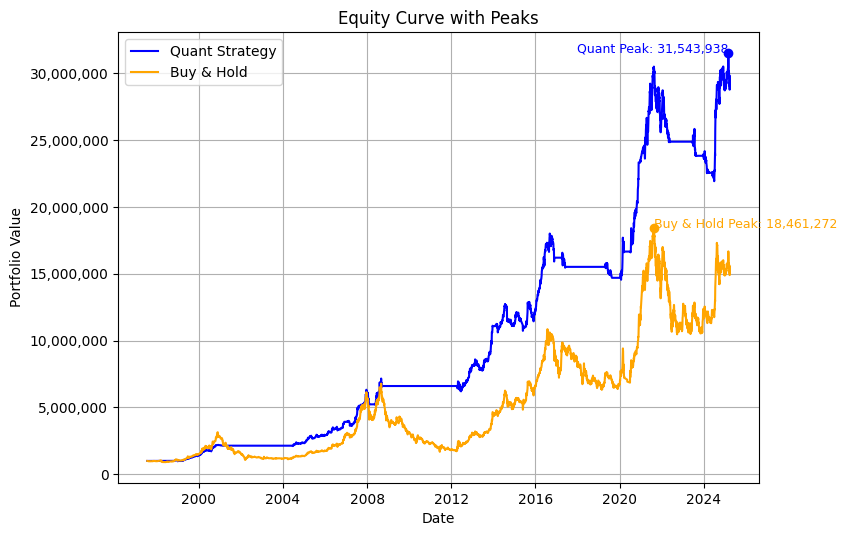

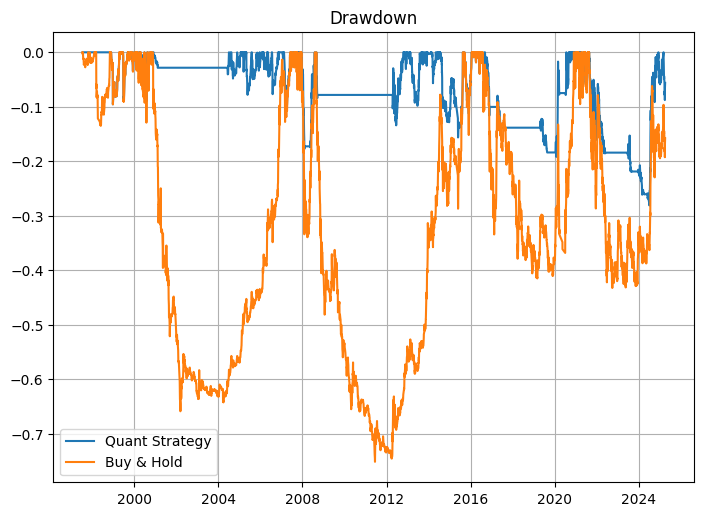

In [13]:
# Plotting
def plot_drawdown(equity, label):
    roll_max = equity.cummax()
    drawdown = (equity - roll_max) / roll_max
    plt.plot(drawdown, label=label)

plt.figure(figsize=(8.27, 5.85))
plt.plot(buy_hold, label="Buy & Hold", color='orange')
plt.scatter(buy_hold.idxmax(), buy_hold.max(), color='orange')
plt.text(buy_hold.idxmax(), buy_hold.max(), f'Peak: {buy_hold.max():,.0f}', color='orange', fontsize=9, ha='left')
plt.title("Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8.27, 5.85))
plt.plot(portfolio, label="Quant Strategy", color='blue')
plt.plot(buy_hold, label="Buy & Hold", color='orange')
plt.scatter(portfolio.idxmax(), portfolio.max(), color='blue')
plt.text(portfolio.idxmax(), portfolio.max(), f'Quant Peak: {portfolio.max():,.0f}', color='blue', fontsize=9, ha='right')
plt.scatter(buy_hold.idxmax(), buy_hold.max(), color='orange')
plt.text(buy_hold.idxmax(), buy_hold.max(), f'Buy & Hold Peak: {buy_hold.max():,.0f}', color='orange', fontsize=9, ha='left')
plt.title("Equity Curve with Peaks")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.legend()
plt.grid(True)

plt.figure(figsize=(8.27, 5.85))
plot_drawdown(portfolio, "Quant Strategy")
plot_drawdown(buy_hold, "Buy & Hold")
plt.title("Drawdown")
plt.legend()
plt.grid(True)
plt.show()


--- Active Days Performance ---
Quant Strategy Mean Daily Log Return: 0.001056
Buy & Hold Mean Daily Log Return: 0.001424
Days in Market: 3150 (49.5% of trading days)
Quant Sharpe: 1.92 | B&H Sharpe: 1.73
Quant Max Drawdown: -29.84%
B&H Max Drawdown: -40.30%


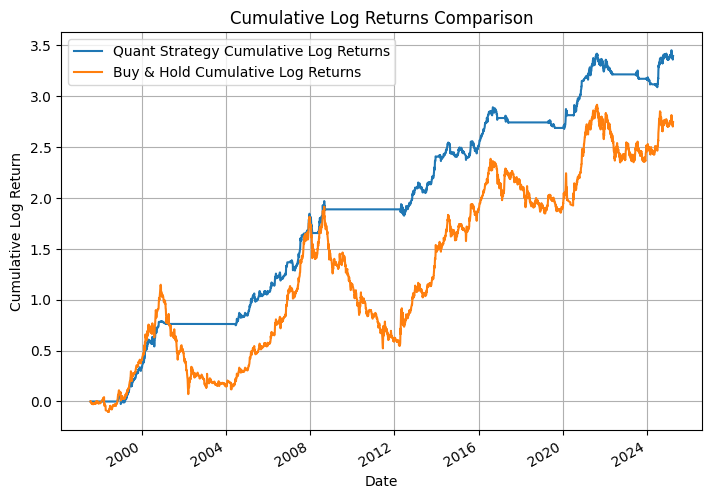

In [12]:
# Calculate log returns for both strategies
quant_log_returns = np.log(portfolio / portfolio.shift(1)).dropna()
buy_hold_log_returns = np.log(buy_hold / buy_hold.shift(1)).dropna()

active_dates = []
for trade in trades:
    entry_date = trade["Date"]
    exit_date = trade.get("Exit Date", entry_date)  # Use exit date if exists, else entry date
    active_dates.extend(pd.date_range(entry_date, exit_date))

# Remove duplicates and keep only market open days (align with data index)
active_dates = sorted(list(set(active_dates)))
active_dates = [date for date in active_dates if date in quant_log_returns.index]

# Filter log returns for active days only
active_quant_returns = quant_log_returns[quant_log_returns.index.isin(active_dates)]
active_bh_returns = buy_hold_log_returns[buy_hold_log_returns.index.isin(active_dates)]

# Create DataFrame with active day returns
active_returns_df = pd.DataFrame({
    'Quant_Strategy_Log_Return': active_quant_returns,
    'Buy_Hold_Log_Return': active_bh_returns
})

print("\n--- Active Days Performance ---")
print(f"Quant Strategy Mean Daily Log Return: {active_quant_returns.mean():.6f}")
print(f"Buy & Hold Mean Daily Log Return: {active_bh_returns.mean():.6f}")
print(f"Days in Market: {len(active_dates)} ({len(active_dates)/len(quant_log_returns):.1%} of trading days)")

# Calculate Sharpe Ratio (higher = better risk-adjusted returns)
risk_free_rate = 0.0  # Adjust if needed
quant_sharpe = (active_quant_returns.mean() - risk_free_rate) / active_quant_returns.std() * np.sqrt(252)
bh_sharpe = (active_bh_returns.mean() - risk_free_rate) / active_bh_returns.std() * np.sqrt(252)
print(f"Quant Sharpe: {quant_sharpe:.2f} | B&H Sharpe: {bh_sharpe:.2f}")

def max_drawdown(returns):
    cumulative = (1 + returns).cumprod()
    peak = cumulative.expanding().max()
    return (cumulative / peak - 1).min()

print(f"Quant Max Drawdown: {max_drawdown(active_quant_returns):.2%}")
print(f"B&H Max Drawdown: {max_drawdown(active_bh_returns):.2%}")

plt.figure(figsize=(8.27, 5.85))
quant_log_returns.cumsum().plot(label='Quant Strategy Cumulative Log Returns')
buy_hold_log_returns.cumsum().plot(label='Buy & Hold Cumulative Log Returns')
plt.title("Cumulative Log Returns Comparison")
plt.ylabel("Cumulative Log Return")
plt.legend()
plt.grid(True)
plt.show()

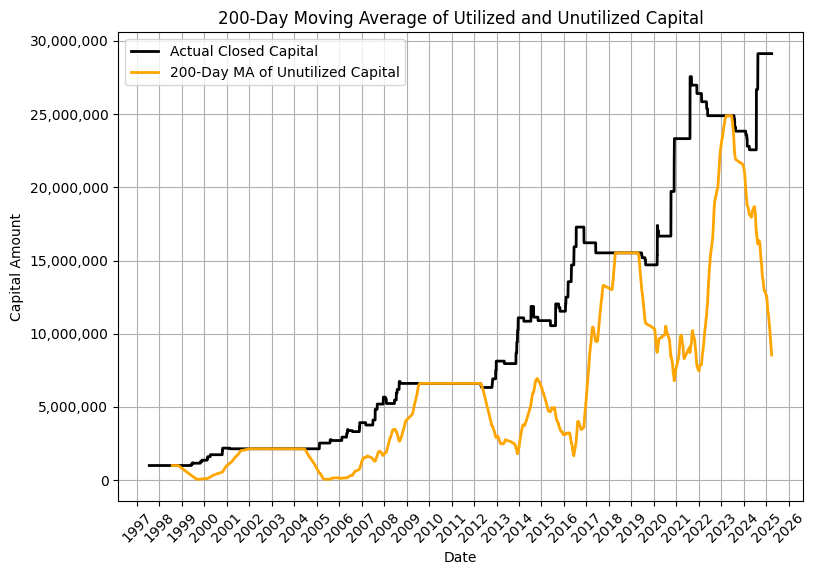

In [14]:
# Create series from lists
cap_index = data.index[:len(actual_cap)]
actual_series = pd.Series(actual_cap, index=cap_index)
used_series = pd.Series(used_cap, index=cap_index)
unused_series = pd.Series(unused_cap, index=cap_index)

# Calculate moving averages (adjust window as needed)
unused_ma = unused_series.rolling(window=200).mean()

# Plotting
plt.figure(figsize=(8.27, 5.85))
plt.plot(actual_series, label="Actual Closed Capital", color='black', linewidth=2)
plt.plot(unused_ma, label="200-Day MA of Unutilized Capital", color='orange', linewidth=2)
plt.title("200-Day Moving Average of Utilized and Unutilized Capital")
plt.xlabel("Date")
plt.ylabel("Capital Amount")
plt.legend()
plt.grid(True)
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.show()


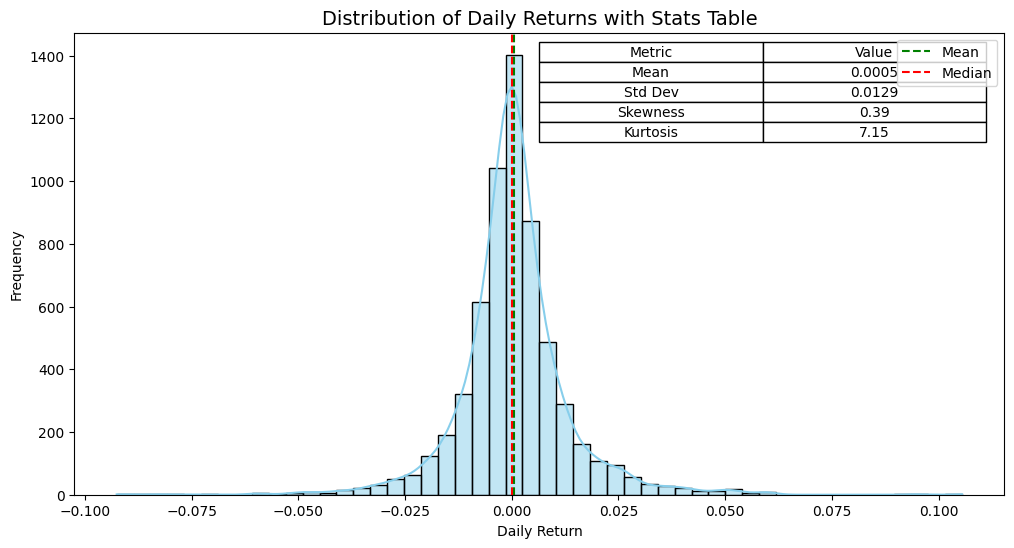

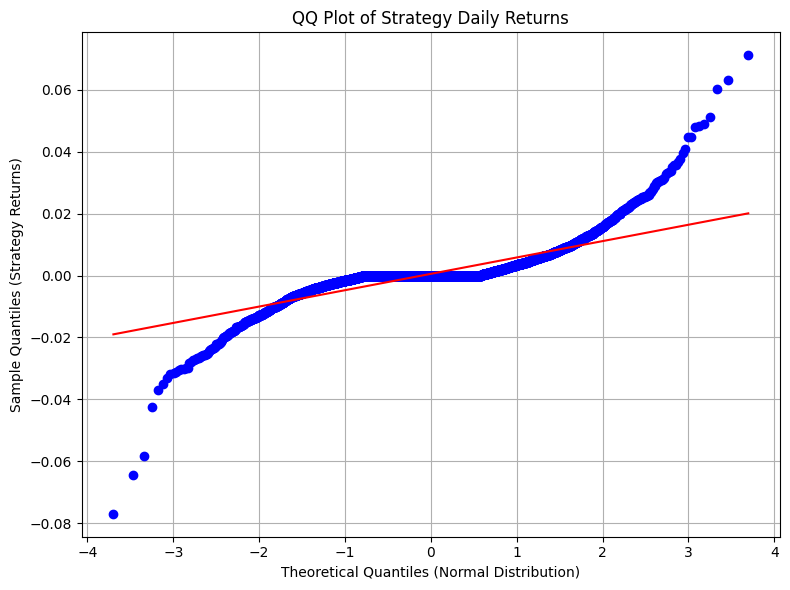

In [ ]:
# Step 1: Calculate returns from Close prices
data['Returns'] = data['Close'].pct_change()
data.dropna(inplace=True)

# Step 2: Calculate distribution statistics
mean_return = data['Returns'].mean()
std_dev = data['Returns'].std()
skewness = skew(data['Returns'])
kurt = kurtosis(data['Returns'])  # Fisher definition (normal = 0)

# Step 3: Plot histogram with KDE and embedded stats table
fig, ax = plt.subplots(figsize=(12, 6))
sns.histplot(data['Returns'], bins=50, kde=True, color='skyblue', ax=ax)
ax.set_title("Distribution of Daily Returns with Stats Table", fontsize=14)
ax.set_xlabel("Daily Return")
ax.set_ylabel("Frequency")
ax.axvline(mean_return, color='green', linestyle='--', label='Mean')
ax.axvline(data['Returns'].median(), color='red', linestyle='--', label='Median')
ax.legend()

# Step 4: Create the statistics table
stats_table = pd.DataFrame({
    'Metric': ['Mean', 'Std Dev', 'Skewness', 'Kurtosis'],
    'Value': [f"{mean_return:.4f}", f"{std_dev:.4f}", f"{skewness:.2f}", f"{kurt:.2f}"]
})

# Add table inside the plot
table = plt.table(cellText=stats_table.values,
                  colLabels=stats_table.columns,
                  cellLoc='center',
                  colWidths=[0.2]*len(stats_table.columns),
                  loc='upper right')
table.scale(1.2, 1.2)

plt.figure(figsize=(8, 6))
stats.probplot(daily_returns, dist="norm", plot=plt)
plt.title("QQ Plot of Strategy Daily Returns")
plt.xlabel("Theoretical Quantiles (Normal Distribution)")
plt.ylabel("Sample Quantiles (Strategy Returns)")
plt.grid(True)
plt.tight_layout()
plt.show()

returns_df = pd.DataFrame({
    'Quant_Strategy': quant_log_returns,
    'Buy_Hold': buy_hold_log_returns
})

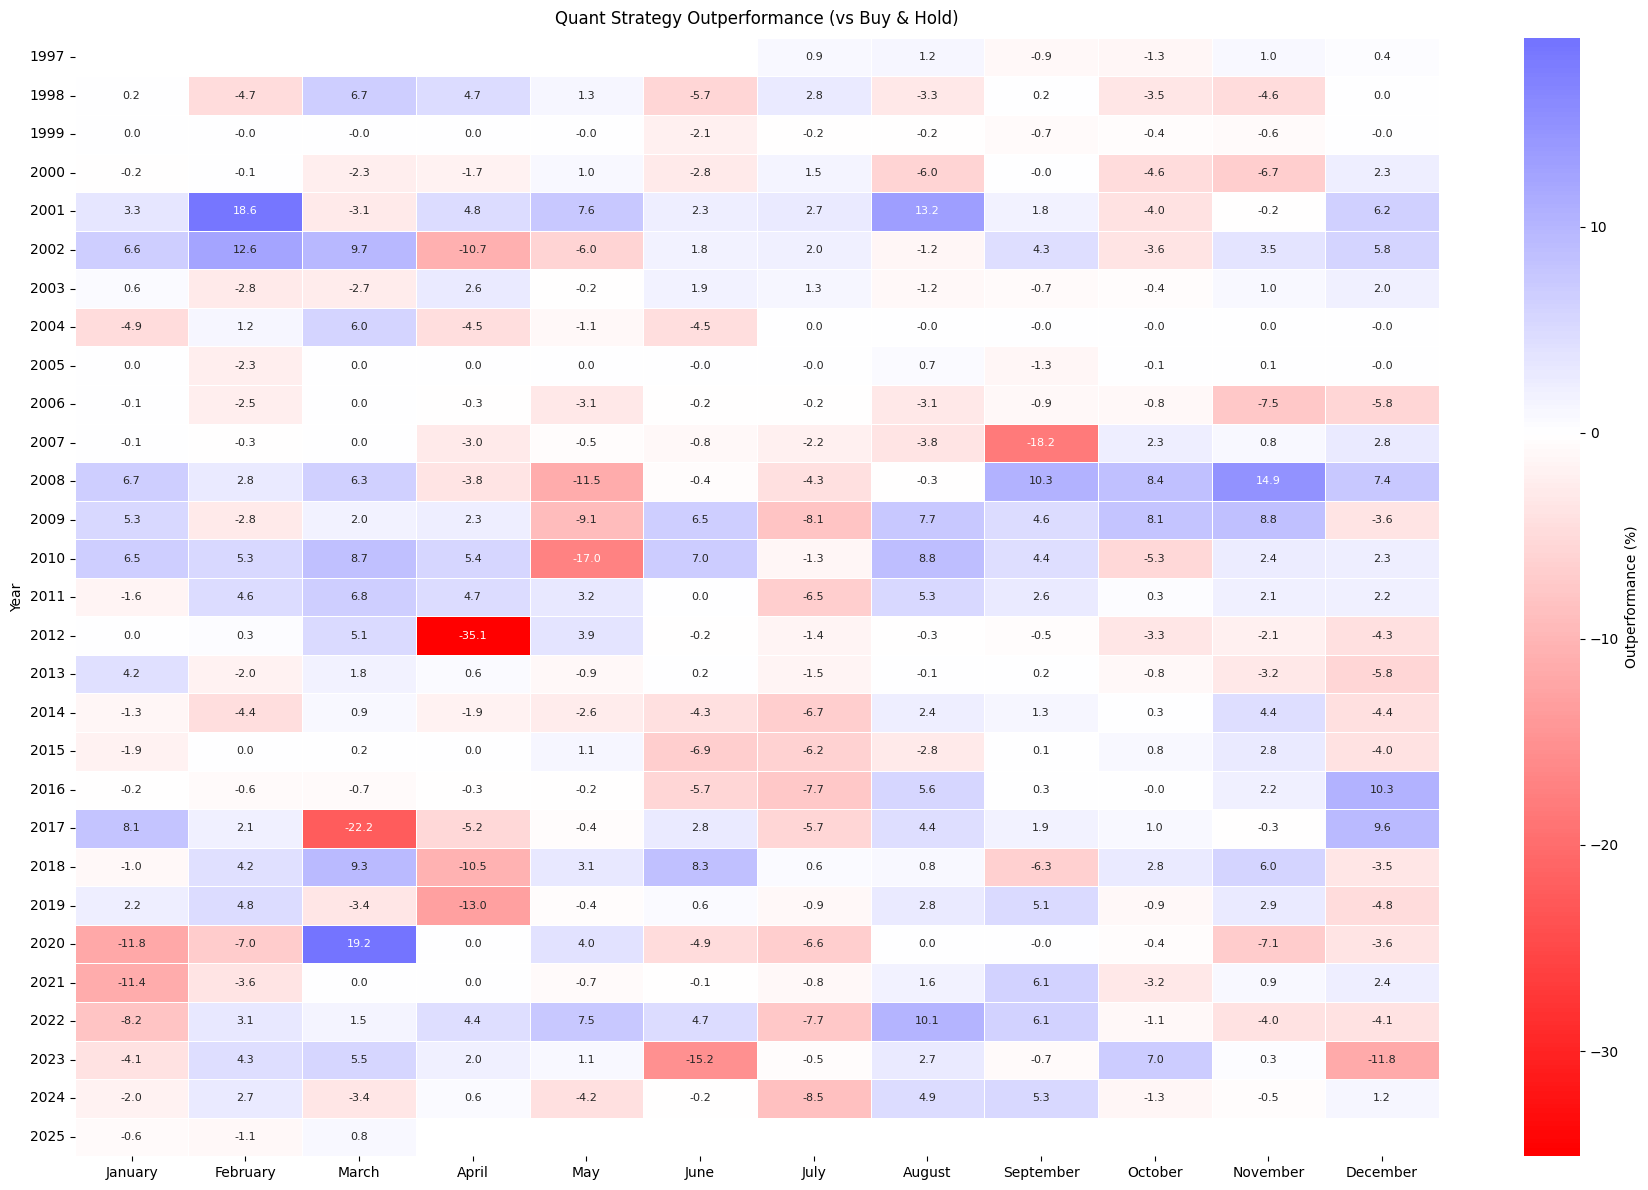

In [16]:
# Create a clean DataFrame with just the returns
returns_df = pd.DataFrame({
    'Date': quant_log_returns.index,
    'Quant_Strategy_Log_Return': quant_log_returns.values,
    'Buy_Hold_Log_Return': buy_hold_log_returns.values
})

monthly_returns = returns_df.set_index('Date').resample('M').apply(lambda x: np.exp(np.sum(x)) - 1)

monthly_returns = returns_df.set_index('Date').resample('M').apply(lambda x: np.exp(np.sum(x)) - 1)

# Extract year and month
monthly_returns['Year'] = monthly_returns.index.year
monthly_returns['Month'] = monthly_returns.index.month_name()

# Reorder months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_returns['Month'] = pd.Categorical(monthly_returns['Month'], categories=month_order, ordered=True)

# Pivot for heatmaps
quant_data = monthly_returns.pivot_table(index='Year', columns='Month', values='Quant_Strategy_Log_Return')
bh_data = monthly_returns.pivot_table(index='Year', columns='Month', values='Buy_Hold_Log_Return')
outperformance_data = quant_data - bh_data

# Calculate statistical significance (t-test)
p_values = pd.DataFrame(index=quant_data.index, columns=quant_data.columns)
for year in quant_data.index:
    for month in quant_data.columns:
        _, p_val = stats.ttest_ind(
            returns_df[returns_df['Date'].dt.month_name() == month]['Quant_Strategy_Log_Return'],
            returns_df[returns_df['Date'].dt.month_name() == month]['Buy_Hold_Log_Return'],
            equal_var=False
        )
        p_values.loc[year, month] = p_val

# Custom colormaps
return_cmap = LinearSegmentedColormap.from_list('returns', ['#FF0000', '#FFFFFF', '#00AA00'], N=256)
outperform_cmap = LinearSegmentedColormap.from_list('outperform', ['#FF0000', '#FFFFFF', '#0000FF'], N=256)

# Create figure
plt.figure(figsize=(18, 12))
outperform_plot = sns.heatmap(outperformance_data * 100, annot=True, fmt=".1f", 
                             cmap=outperform_cmap, center=0, linewidths=0.5,
                             annot_kws={'size': 8}, cbar_kws={'label': 'Outperformance (%)'})
plt.title('Quant Strategy Outperformance (vs Buy & Hold)', pad=10)
plt.xlabel('')
plt.ylabel('Year')

# Add significance markers (*p<0.05, **p<0.01)
for (y, m), p_val in np.ndenumerate(p_values.values):
    if p_val < 0.01:
        outperform_plot.text(m + 0.5, y + 0.5, '**', ha='center', va='center', color='black')
    elif p_val < 0.05:
        outperform_plot.text(m + 0.5, y + 0.5, '*', ha='center', va='center', color='black')

plt.tight_layout()
plt.savefig('enhanced_monthly_heatmaps.png', dpi=300, bbox_inches='tight')
plt.show()